# 01 – Generate 2D initial data

This notebook reproduces the `ini_dat_v2.ipynb` workflow using the refactored `PIC` module.

In [ ]:
using Pkg
Pkg.activate(joinpath(@__DIR__, ".."))
Pkg.instantiate()


In [1]:
cd(@__DIR__)
include(joinpath("..","src","PIC.jl"))
using .PIC
using Plots
using Statistics
using FFTW
using LinearAlgebra

const N_exp = 5
const N = 10^N_exp
const order = 5
const factor = 2

J = (50, 50)
box = Box((0.0, 1.0, 0.0, 1.0))
nm = [1, 1]
alpha_exp = 1
α = 10.0^(-alpha_exp)
θ_exp = 3
θ = 10.0^(-θ_exp)
p_max = sqrt((1 + 10θ)^2 - 1)
box_p = Box((-p_max, p_max, -p_max, p_max))

data_name = "par_dis_rel_thermal_nm_[$(nm[1]),$(nm[2])]_alp$(alpha_exp)_N$(N_exp)_Th$(θ_exp)"
par_f_x = (α, nm, box)
par_f_p = (θ, 2)

par_dis = build_initial_data_D(
    joinpath("..", "Initial_Distributions", data_name),
    N,
    f_x, f_x_max, par_f_x, box,
    f_p_thermal, f_p_thermal_max, par_f_p, box_p
)

println("Saved to: Initial_Distributions/$(data_name).jld2")
println("length(par_dis) = ", length(par_dis))


Saved to: Initial_Distributions/par_dis_rel_thermal_nm_[1,1]_alp1_N5_Th3.jld2
length(par_dis) = 400000


## Reshape into (N, 4) matrix for convenience

In [2]:
# Reshape into N×4: [x, y, px, py]

r = reshape(par_dis, (4, N))'
x = r[:, 1]
y = r[:, 2]
px = r[:, 3]
py = r[:, 4]


100000-element Vector{Float64}:
  0.006465276603845882
  0.019067151643143293
 -0.007593677365153234
  0.041808354849795615
 -0.03691573802930252
  0.005301731538182752
  0.0007977757748319492
  0.014078076389826388
 -0.04063156197112934
  0.027557445322496404
  ⋮
  0.06628144184498276
  0.02311947525402036
 -0.01011422603404133
 -0.019606136383493622
 -0.04690328723260867
  0.006292937933463444
  0.02430176684188451
 -0.025555109552660632
 -0.07235347696216243

## Diagnostic checks

In [3]:
## Diagnostic checks

# Build a minimal state so we can use module diagnostics
g_dummy = PICGrid(box, J, order)
u_dummy = make_state(g_dummy, N)
u_dummy[1:4N] .= par_dis

# Temperatures
T_rel = temperature(u_dummy, g_dummy, N; mode=:rel)
T_norel = temperature(u_dummy, g_dummy, N; mode=:norel)
println("relativistic temperature T = ", T_rel, "  (target θ = ", θ, ")")
println("non-relativistic temperature T = ", T_norel, "  (target θ/2 = ", θ/2, ")")

# Total momentum (should be ~0 because symmetric pairs were generated)
P_total = total_momentum(u_dummy, g_dummy, N)
println("total momentum P = ", P_total)
println("|P|/N = ", norm(P_total) / N)

println("x range: ", extrema(x))
println("y range: ", extrema(y))
println("<px^2> = ", mean(px.^2), "  (θ/2 = ", θ/2, ")")
println("<py^2> = ", mean(py.^2), "  (θ/2 = ", θ/2, ")")


relativistic temperature T = 0.000997758533670837  (target θ = 0.001)
non-relativistic temperature T = 0.0009977585336708528  (target θ/2 = 0.0005)
total momentum P = [-1.2378986724570495e-14, -2.070565940925917e-14]
|P|/N = 2.4123922647433097e-19
x range: (3.501470340339097e-7, 0.999972563343311)
y range: (7.948104632449216e-6, 0.9999963108376841)
<px^2> = 0.0009979897924014942  (θ/2 = 0.0005)
<py^2> = 0.0009975272749401822  (θ/2 = 0.0005)


## Spatial plots

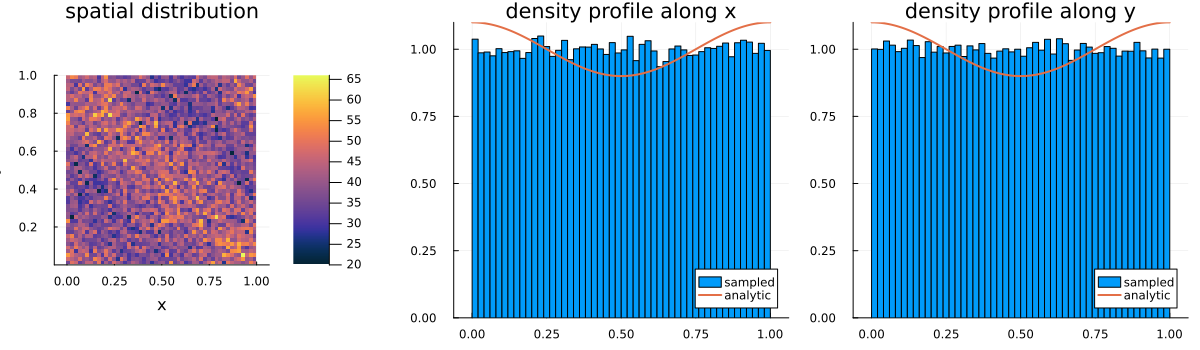

In [4]:
## Spatial plots

# 2D histogram of particle positions
h2 = histogram2d(x, y, bins=50,
    title="spatial distribution", c=:thermal, aspectratio=1,
    xlabel="x", ylabel="y")

# 1D projection along x and comparison with analytic profile (to check this use nm = [n,0])
hx = histogram(x, bins=50, normalize=true, label="sampled", title="density profile along x")
kx = 2π * nm[1] / extent(box, 1)
analytic_x = xx -> (1 + α * cos(kx * xx)) / extent(box, 1)
xx = range(box.lo[1], box.hi[1], length=200)
plot!(hx, xx, analytic_x.(xx), lw=2, label="analytic")

# 1D projection along y and comparison with analytic profile (to check this use nm = [0,m])
hy = histogram(y, bins=50, normalize=true, label="sampled", title="density profile along y")
ky = 2π * nm[2] / extent(box, 2)
analytic_y = yy -> (1 + α * cos(ky * yy)) / extent(box, 2)
yy = range(box.lo[2], box.hi[2], length=200)
plot!(hy, yy, analytic_y.(yy), lw=2, label="analytic")

plot(h2, hx, hy, layout=(1, 3), size=(1200, 350))


## Momentum plots

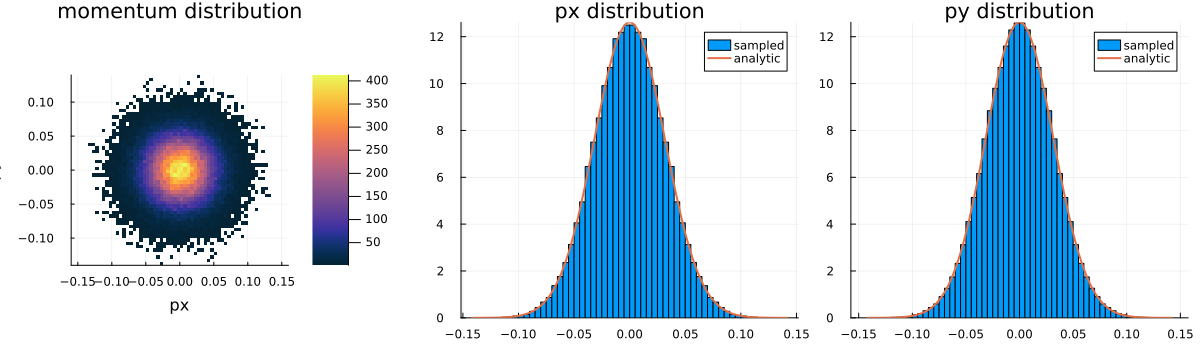

In [5]:
## Momentum plots

# 2D histogram of momenta
mp2 = histogram2d(px, py, bins=50,
    title="momentum distribution", c=:thermal, aspectratio=1,
    xlabel="px", ylabel="py")

# 1D histograms with analytic thermal profile
analytic_p = pp -> exp(-pp.^2 / θ / 2) / sqrt(θ * π * 2)
pp = range(-p_max, p_max, length=200)

hpx = histogram(px, bins=50, normalize=true, label="sampled", title="px distribution")
plot!(hpx, pp, analytic_p.(pp), lw=2, label="analytic")

hpy = histogram(py, bins=50, normalize=true, label="sampled", title="py distribution")
plot!(hpy, pp, analytic_p.(pp), lw=2, label="analytic")

plot(mp2, hpx, hpy, layout=(1, 3), size=(1200, 350))


## Scatter plots of the first few thousand particles

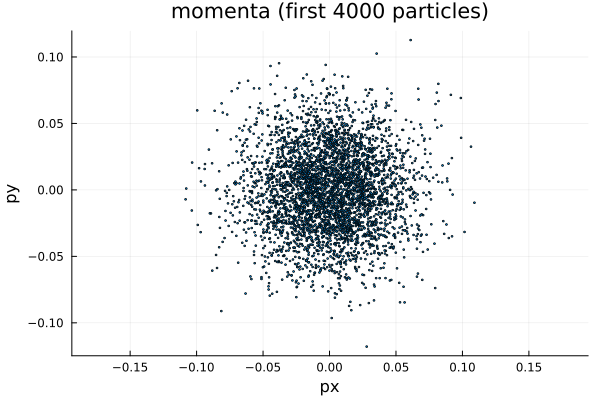

In [6]:
## Scatter plots of the first few thousand particles

nplot = min(N, 4000)
scatter(x[1:nplot], y[1:nplot],
    title="positions (first $nplot particles)", aspectratio=1,
    xlabel="x", ylabel="y", markersize=1, label=false)

scatter(px[1:nplot], py[1:nplot],
    title="momenta (first $nplot particles)", aspectratio=1,
    xlabel="px", ylabel="py", markersize=1, label=false)
